# "외부관광객이 많이 방문하지만 지출은 낮은 지역" 판별

## [1] 데이터셋 A — 여행시기·지출 구조 파악

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## [1] 데이터셋 A — 여행시기·지출 구조 파악

In [41]:
pd.set_option('display.max_columns', None)

df = pd.read_csv(r'C:\Users\soo\Documents\github\out-traveler\data\processed\travel_timing_expenditure_2025.csv')
print(df.shape)


(14342, 38)


In [42]:
suffix_x_columns = [c for c in df.columns if c.endswith('_x')]
candidate_fields = [c[:-2] for c in suffix_x_columns if c[:-2] + '_y' in df.columns]

redundant_fields = []
for field in candidate_fields:
    identical_ratio = (df[field + '_x'].fillna('NA_TOKEN') == df[field + '_y'].fillna('NA_TOKEN')).mean()
    if identical_ratio == 1.0:
        redundant_fields.append(field)

df = df.drop(columns=[f + '_y' for f in redundant_fields])
df = df.rename(columns={f + '_x': f for f in redundant_fields})
print(f'중복쌍 {len(candidate_fields)}개 중 {len(redundant_fields)}개 병합')
print(df.shape)


중복쌍 11개 중 11개 병합
(14342, 27)


In [43]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv(r'C:\Users\soo\Documents\github\out-traveler\data\processed\travel_timing_expenditure_2025.csv')
print(df.shape)


(14342, 38)


In [44]:
suffix_x_columns = [c for c in df.columns if c.endswith('_x')]
candidate_fields = [c[:-2] for c in suffix_x_columns if c[:-2] + '_y' in df.columns]

redundant_fields = []
for field in candidate_fields:
    identical_ratio = (df[field + '_x'].fillna('NA_TOKEN') == df[field + '_y'].fillna('NA_TOKEN')).mean()
    if identical_ratio == 1.0:
        redundant_fields.append(field)

df = df.drop(columns=[f + '_y' for f in redundant_fields])
df = df.rename(columns={f + '_x': f for f in redundant_fields})
print(f'중복쌍 {len(candidate_fields)}개 중 {len(redundant_fields)}개 병합')
print(df.shape)


중복쌍 11개 중 11개 병합
(14342, 27)


### 컬럼 스코프 — "외부관광객 방문·지출 격차 판별"에 필요한 컬럼만

✔️ 이번 목표(외부관광객 여부 판별)엔 응답자 거주지역이 필수이나, 그 정보는 데이터셋 A가 아니라 **데이터셋 B에만 존재** → A는 여행지·지출·조인키·무결성 검증용 컬럼만 남기고, 거주지역은 뒤에서 B와 결합해 확보

In [45]:
scope_fields = ['RESPOND_ID','EXAMIN_BEGIN_DE','TOUR_CTPRVN_NM','TOUR_BEGIN_DE','TOUR_PD_VALUE',
                'TOUR_COM_NMPR_NM','SEXDSTN_FLAG_CD','AGRDE_FLAG_NM',
                'TOUR_TOT_CT_VALUE','TOUR_LDGMNT_CT_VALUE','TOUR_FOOD_CT_VALUE',
                'TOUR_TRNSPORT_CT_VALUE','TOUR_SHOPNG_CT_VALUE','TOUR_ACTVTY_CT_VALUE','TOUR_ETC_CT_VALUE']
df = df[scope_fields]
print(df.shape)


(14342, 15)


### 결측치 처리 (A)

In [46]:
def blank_flag(s):
    return s.isna() | s.astype(str).str.contains('모름', na=False)

rows = []
for col in df.columns:
    n = blank_flag(df[col]).sum()
    rows.append({'field': col, 'blank_n': n, 'blank_pct': round(n/len(df)*100, 2)})
summary = pd.DataFrame(rows).set_index('field')
print(summary[summary['blank_n'] > 0].sort_values('blank_pct', ascending=False))


                        blank_n  blank_pct
field                                     
TOUR_TOT_CT_VALUE          2639      18.40
TOUR_ACTVTY_CT_VALUE       2639      18.40
TOUR_LDGMNT_CT_VALUE       2639      18.40
TOUR_FOOD_CT_VALUE         2639      18.40
TOUR_TRNSPORT_CT_VALUE     2639      18.40
TOUR_ETC_CT_VALUE          2639      18.40
TOUR_SHOPNG_CT_VALUE       2639      18.40
TOUR_COM_NMPR_NM            453       3.16
TOUR_PD_VALUE               144       1.00


In [47]:
before_n = len(df)
df = df[~blank_flag(df['TOUR_TOT_CT_VALUE'])].copy()
df = df[~blank_flag(df['TOUR_COM_NMPR_NM'])].copy()
df = df[~blank_flag(df['TOUR_PD_VALUE'])].copy()
print(f'{before_n} -> {len(df)}')


14342 -> 11255


## [2] 데이터셋 B — 숙박여행유형(거주지역 포함) 구조 파악

In [48]:
acc = pd.read_csv(r'C:\Users\soo\Documents\github\out-traveler\data\processed\accommodation_type_2025.csv')
print(acc.shape)
print(acc.columns.tolist())


(19803, 8)
['RESPOND_ID', 'EXAMIN_YM', 'SEXDSTN_FLAG_CD', 'AGRDE_FLAG_NM', 'ANSWRR_OC_AREA_NM', 'HSHLD_INCOME_DGREE_NM', 'DMSTC_TOUR_TY_VALUE', 'OVSEA_TOUR_TY_VALUE']


✔️ 이번 목표에서 `ANSWRR_OC_AREA_NM`(거주지역)은 참고용이 아니라 **핵심 판별축** — 결측 여부부터 확인

In [49]:
print('거주지역 결측:', acc['ANSWRR_OC_AREA_NM'].isna().sum())

before_n = len(acc)
acc = acc.drop_duplicates(subset=['RESPOND_ID','EXAMIN_YM'], keep='first')

sex_wobble = acc.groupby('RESPOND_ID')['SEXDSTN_FLAG_CD'].nunique()
wobble_ids = set(sex_wobble[sex_wobble > 1].index)
age_scale = {'20대':20, '30대':30, '40대':40, '50대':50, '60대':60}
acc['age_score'] = acc['AGRDE_FLAG_NM'].map(age_scale)
age_wobble = acc.groupby('RESPOND_ID')['age_score'].agg(lambda s: s.max() - s.min())
wobble_ids |= set(age_wobble[age_wobble >= 20].index)
acc = acc[~acc['RESPOND_ID'].isin(wobble_ids)].copy()
print(f'중복+속성흔들림({len(wobble_ids)}명) 제거: {before_n} -> {len(acc)}')


거주지역 결측: 0
중복+속성흔들림(49명) 제거: 19803 -> 19668


✔️ 거주지역 자체가 바뀐 응답자(220명)는 삭제하지 않음 — 이사는 정상적 변화.

## [3] 데이터셋 결합 — 거주지역 매핑 후 조인

In [50]:
name_norm = {
    '광주광역시':'광주시', '대구광역시':'대구시', '대전광역시':'대전시', '부산광역시':'부산시',
    '서울특별시':'서울시', '울산광역시':'울산시', '인천광역시':'인천시', '충청남도(세종시 포함)':'충청남도'
}
acc['home_region'] = acc['ANSWRR_OC_AREA_NM'].replace(name_norm)

df['examin_ym'] = df['EXAMIN_BEGIN_DE'] // 100
joined = df.merge(acc[['RESPOND_ID','EXAMIN_YM','home_region']],
                   left_on=['RESPOND_ID','examin_ym'], right_on=['RESPOND_ID','EXAMIN_YM'], how='left')

before_n = len(joined)
unmatched_n = joined['home_region'].isna().sum()
print(f'조인 실패(거주지역 정보 없음): {unmatched_n}건 ({unmatched_n/before_n*100:.2f}%)')

joined = joined.dropna(subset=['home_region']).copy()
print(f'결합 데이터: {before_n} -> {len(joined)}')


조인 실패(거주지역 정보 없음): 328건 (2.91%)
결합 데이터: 11255 -> 10927


✔️ 조인 실패 2.91%는 대체할 원천이 없어 행 삭제 — 이번 목표(외부관광객 여부 판별)엔 거주지역이 필수라 결측 허용 불가

In [51]:
joined['is_outsider_trip'] = joined['TOUR_CTPRVN_NM'] != joined['home_region']
outsider_n = joined['is_outsider_trip'].sum()
print(f'외부관광객 여행: {outsider_n}건 / 역내여행: {len(joined) - outsider_n}건')

df = joined[joined['is_outsider_trip']].copy()
print(f'외부관광객만 스코프: {len(joined)} -> {len(df)}')


외부관광객 여행: 9717건 / 역내여행: 1210건
외부관광객만 스코프: 10927 -> 9717


## [4] 이상치 진단 — 1인당 지출 기준 (외부관광객만)

In [52]:
headcount_map = {'혼자서':1, '2명':2, '3명':3, '4명':4, '5명 이상':5}
budget_map = {'10만원 미만':5, '10~20만원 미만':15, '20~30만원 미만':25, '30~40만원 미만':35, '40만원 이상':45}

df['headcount'] = df['TOUR_COM_NMPR_NM'].map(headcount_map)
df['budget_mid'] = df['TOUR_TOT_CT_VALUE'].map(budget_map)
df['per_head_spend'] = df['budget_mid'] / df['headcount']

q1, q3 = df['per_head_spend'].quantile([0.25, 0.75])
band = q3 - q1
floor, ceiling = q1 - 1.5*band, q3 + 1.5*band
flagged = df[(df['per_head_spend'] < floor) | (df['per_head_spend'] > ceiling)]
print(f'이상범위 {len(flagged)}건 ({len(flagged)/len(df)*100:.2f}%)')
print(flagged['headcount'].value_counts())


이상범위 375건 (3.86%)
headcount
1    375
Name: count, dtype: int64


✔️ 처리하지 않음 — 전부 `headcount=1`(나홀로), 분담 인원이 없어 1인당 지출=총지출이 되는 정의상 결과

## [5] 손상 레코드 검증 (외부관광객 스코프)

In [53]:
df['survey_date'] = pd.to_datetime(df['EXAMIN_BEGIN_DE'], format='%Y%m%d')
df['trip_date'] = pd.to_datetime(df['TOUR_BEGIN_DE'], format='%Y%m%d')

reversed_cases = df[df['trip_date'] > df['survey_date']]
print(f'[1] 시점 역전: {len(reversed_cases)}건')


[1] 시점 역전: 33건


✔️ 처리하지 않음 — 조사window(주 단위) 특성상 정상 범위

In [54]:
sex_wobble = df.groupby('RESPOND_ID')['SEXDSTN_FLAG_CD'].nunique()
wobble_ids = set(sex_wobble[sex_wobble > 1].index)
age_scale = {'20대':20, '30대':30, '40대':40, '50대':50, '60대 이상':60}
df['age_score'] = df['AGRDE_FLAG_NM'].map(age_scale)
age_wobble = df.groupby('RESPOND_ID')['age_score'].agg(lambda s: s.max() - s.min())
wobble_ids |= set(age_wobble[age_wobble >= 20].index)
print(f'[2] 동일인 속성 흔들림: {len(wobble_ids)}명')
df = df[~df['RESPOND_ID'].isin(wobble_ids)].copy()
print(f'제거 후: {len(df)}행')


[2] 동일인 속성 흔들림: 0명
제거 후: 9717행


In [55]:
recheck = df.groupby(['RESPOND_ID','TOUR_BEGIN_DE']).size()
recheck_dup = recheck[recheck > 1]
print(f'[3] 재조사 중복: {len(recheck_dup)}그룹, 잉여 {(recheck_dup-1).sum()}건')

df = df.sort_values('EXAMIN_BEGIN_DE').drop_duplicates(subset=['RESPOND_ID','TOUR_BEGIN_DE'], keep='last')
print(f'최신 회차만 유지 후: {len(df)}행')


[3] 재조사 중복: 56그룹, 잉여 60건


최신 회차만 유지 후: 9657행


In [56]:
duration_map = {'1박 2일':2, '2박 3일':3, '3박 4일':4, '4박 5일':5, '5박 6일':6, '6박 7일 이상':7}
df['stay_len'] = df['TOUR_PD_VALUE'].map(duration_map)
df['trip_date'] = pd.to_datetime(df['TOUR_BEGIN_DE'], format='%Y%m%d')
df['trip_end'] = df['trip_date'] + pd.to_timedelta(df['stay_len'] - 1, unit='D')

clash_rows = []
for rid, grp in df.groupby('RESPOND_ID'):
    if len(grp) < 2:
        continue
    grp = grp.sort_values('trip_date')
    idxs = grp.index.tolist()
    for i in range(len(idxs) - 1):
        if grp.loc[idxs[i+1], 'trip_date'] < grp.loc[idxs[i], 'trip_end']:
            older = idxs[i] if grp.loc[idxs[i], 'EXAMIN_BEGIN_DE'] <= grp.loc[idxs[i+1], 'EXAMIN_BEGIN_DE'] else idxs[i+1]
            clash_rows.append(older)

print(f'[4] 일정 겹침: {len(set(clash_rows))}건')
df = df.drop(index=set(clash_rows))
print(f'삭제 후: {len(df)}행 / {df["TOUR_CTPRVN_NM"].nunique()}개 지역')


[4] 일정 겹침: 15건
삭제 후: 9642행 / 16개 지역


### 단계별 행 수 변화

| 단계 | 행 수 |
| --- | --- |
| A 원본 | 14,342 |
| A 결측치 처리 | 11,255 |
| B와 결합(거주지역 확보) | 10,927 |
| 외부관광객만 스코프 | 9,717 |
| 동일인 속성 흔들림 제거 | 9,717 |
| 재조사 중복(최신회차만) | 9,657 |
| 일정 겹침 제거 | **9,642** |


## [6] EDA — 지역별 외부관광객 방문·지출 교차 판별

In [57]:
print(df.columns)

Index(['RESPOND_ID', 'EXAMIN_BEGIN_DE', 'TOUR_CTPRVN_NM', 'TOUR_BEGIN_DE',
       'TOUR_PD_VALUE', 'TOUR_COM_NMPR_NM', 'SEXDSTN_FLAG_CD', 'AGRDE_FLAG_NM',
       'TOUR_TOT_CT_VALUE', 'TOUR_LDGMNT_CT_VALUE', 'TOUR_FOOD_CT_VALUE',
       'TOUR_TRNSPORT_CT_VALUE', 'TOUR_SHOPNG_CT_VALUE',
       'TOUR_ACTVTY_CT_VALUE', 'TOUR_ETC_CT_VALUE', 'examin_ym', 'EXAMIN_YM',
       'home_region', 'is_outsider_trip', 'headcount', 'budget_mid',
       'per_head_spend', 'survey_date', 'trip_date', 'age_score', 'stay_len',
       'trip_end'],
      dtype='str')


In [58]:
region = df.groupby('TOUR_CTPRVN_NM').agg(
    outsider_visit_n=('RESPOND_ID', 'count'),
    outsider_per_head_avg=('per_head_spend', 'mean')
).reset_index()

visit_cut = region['outsider_visit_n'].median()
spend_cut = region['outsider_per_head_avg'].median()
print('외부방문 중앙값:', visit_cut, '/ 외부 1인당지출 중앙값:', round(spend_cut, 2))

def quadrant(row):
    if row['outsider_visit_n'] >= visit_cut and row['outsider_per_head_avg'] < spend_cut:
        return '고방문·저지출(목표)'
    elif row['outsider_visit_n'] >= visit_cut:
        return '고방문·고지출'
    elif row['outsider_per_head_avg'] < spend_cut:
        return '저방문·저지출'
    else:
        return '저방문·고지출'

region['quadrant'] = region.apply(quadrant, axis=1)
region = region.sort_values(['quadrant', 'outsider_visit_n'], ascending=[True, False])
print(region.round(2).to_string(index=False))


외부방문 중앙값: 558.0 / 외부 1인당지출 중앙값: 9.95
TOUR_CTPRVN_NM  outsider_visit_n  outsider_per_head_avg    quadrant
           강원도              2197                  10.02     고방문·고지출
           부산시               823                  13.25     고방문·고지출
          전라남도               799                  10.47     고방문·고지출
           제주도               772                  16.55     고방문·고지출
           서울시               636                  13.91     고방문·고지출
          경상북도               788                   9.37 고방문·저지출(목표)
           경기도               565                   9.56 고방문·저지출(목표)
          경상남도               558                   9.31 고방문·저지출(목표)
          충청남도               558                   8.50 고방문·저지출(목표)
           대전시               267                  10.80     저방문·고지출
           대구시               238                  11.29     저방문·고지출
           광주시               101                  13.15     저방문·고지출
          전라북도               520                   9.75     저방문·저지출
          충

### 판별 결과

**"외부관광객이 많이 방문하지만 지출은 낮은 지역" = 경상북도, 경기도, 경상남도, 충청남도**

✔️ 이전(전체 방문객 기준) 판별 결과였던 **강원도가 이번엔 제외**됨 — 역내 당일치기 방문객을 제거하고 순수 외부관광객만 남기자, 강원도의 1인당 지출이 중앙값(9.95) 이상(10.02)으로 올라갔기 때문
✔️ 대신 **충청남도가 새로 포함**됨

## [7] EDA 그래프

In [62]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 윈도우 기본 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 그래프 1 — 지역별 외부관광객 방문건수

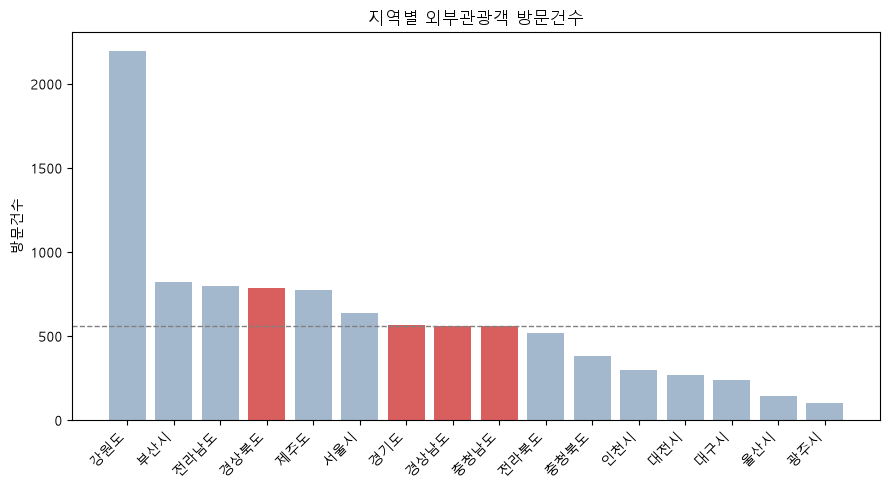

In [63]:
region1 = region.sort_values('outsider_visit_n', ascending=False)
target_regions = ['경상북도','경기도','경상남도','충청남도']
colors1 = ['#d95f5f' if r in target_regions else '#a3b8cc' for r in region1['TOUR_CTPRVN_NM']]

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(region1['TOUR_CTPRVN_NM'], region1['outsider_visit_n'], color=colors1)
ax.axhline(visit_cut, color='gray', linestyle='--', linewidth=1)
ax.set_title('지역별 외부관광객 방문건수')
ax.set_ylabel('방문건수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 그래프 2 — 지역별 1인당 평균지출

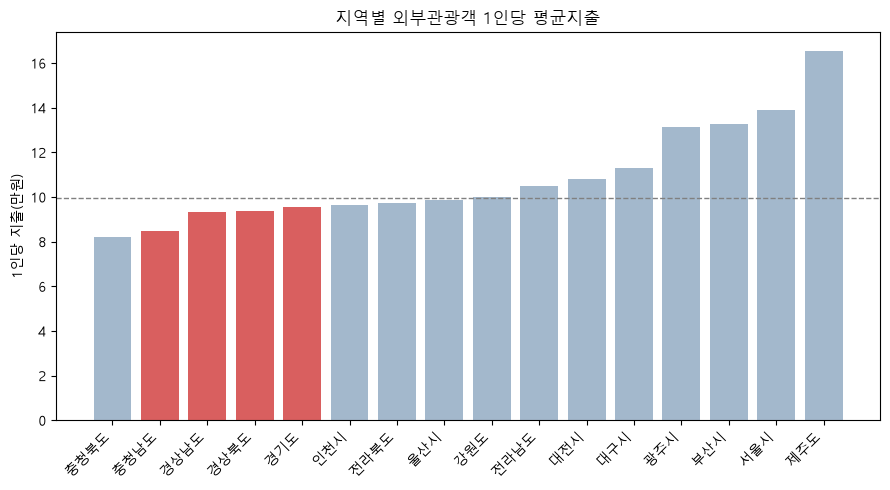

In [64]:
region2 = region.sort_values('outsider_per_head_avg')
colors2 = ['#d95f5f' if r in target_regions else '#a3b8cc' for r in region2['TOUR_CTPRVN_NM']]

fig, ax = plt.subplots(figsize=(9,5))
ax.bar(region2['TOUR_CTPRVN_NM'], region2['outsider_per_head_avg'], color=colors2)
ax.axhline(spend_cut, color='gray', linestyle='--', linewidth=1)
ax.set_title('지역별 외부관광객 1인당 평균지출')
ax.set_ylabel('1인당 지출(만원)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 그래프 3 — 방문·지출 사분면 산점도
빨간 점 = 고방문·저지출(목표) 지역, 점선 = 중앙값 기준선

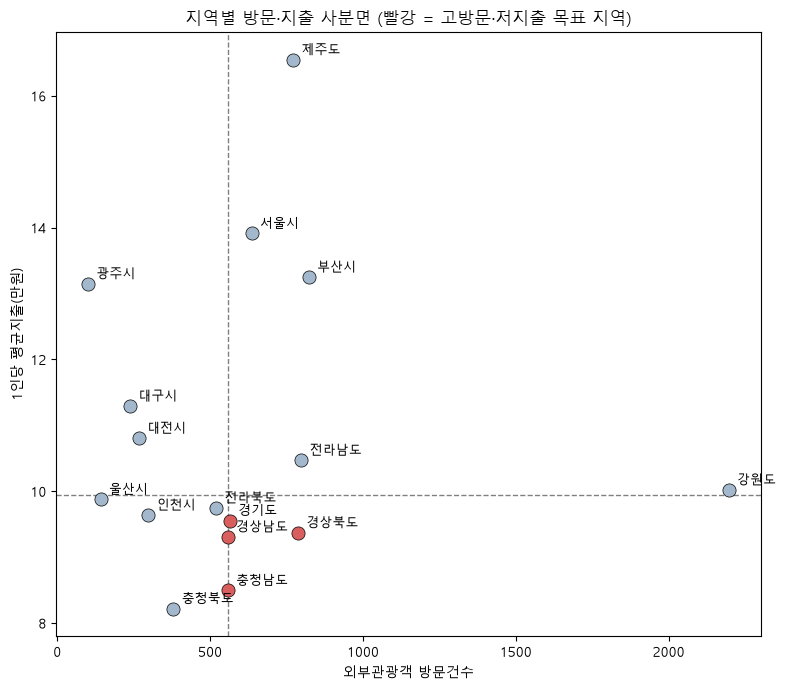

In [65]:
fig, ax = plt.subplots(figsize=(8,7))
for _, row in region.iterrows():
    color = '#d95f5f' if row['TOUR_CTPRVN_NM'] in target_regions else '#a3b8cc'
    ax.scatter(row['outsider_visit_n'], row['outsider_per_head_avg'], s=90,
               color=color, edgecolor='black', linewidth=0.5, zorder=3)
    ax.annotate(row['TOUR_CTPRVN_NM'], (row['outsider_visit_n'], row['outsider_per_head_avg']),
                textcoords='offset points', xytext=(6,4), fontsize=9)
ax.axvline(visit_cut, color='gray', linestyle='--', linewidth=1)
ax.axhline(spend_cut, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('외부관광객 방문건수')
ax.set_ylabel('1인당 평균지출(만원)')
ax.set_title('지역별 방문·지출 사분면 (빨강 = 고방문·저지출 목표 지역)')
plt.tight_layout()
plt.show()
